# SMACNP Predictions: PeakWeather Train Context → PeakWeather Test Stations

This notebook loads a trained SMACNP model (from **training_notebook_pw.ipynb** or **training_notebook_MS_PWstations.ipynb**) and evaluates it on the 35 held-out PeakWeather test stations.

**Data flow:** 103 PW train-station readings (context) → SMACNP → predictions at 35 held-out PW test stations → compared against PW ground truth.

For each fold, we:
1. Load the trained model checkpoint
2. Identify the holdout time period for that fold
3. Generate predictions at the 35 test stations for every day in the holdout period
4. Plot an observed-vs-predicted scatter for one representative holdout day

After all folds, the holdout predictions are concatenated (non-overlapping time periods) to produce a unified evaluation:
- Per-station error maps (MAE, RMSE, Bias)
- Uncertainty calibration (predicted σ vs actual error per station)
- Error correlations with altitude and mTPI
- Temporal error patterns (day-of-year analysis)
- CRPS for probabilistic calibration
- Skill score relative to regression kriging baseline
- Q-Q plot (PIT-based) and reliability diagram


In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
MODEL_NAME = 'test-2017-50e-5f-smacnp-pw-mean-v26'
PW_FIRST_DATE = '2017-01-01'
PW_LAST_DATE = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99
STATION_SPLIT_SEED = 42   # must match training notebook exactly


In [3]:
from pathlib import Path

import params

params.configure_renku_cuda()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import datasets as ds
import inference as inf
import metrics
import model_factory
import visualization as vis
from convCNP.training.training_elev import get_fold_holdout_indices, select_holdout_day

/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_crps.py:257: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z (F(z) - H(z - x))^2 dz
/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_brier.py:10: SyntaxWarning: invalid escape sequence '\i'
  The Brier score (BS) scores binary forecasts $k \in \{0, 1\}$,
/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_brier.py:102: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z BS(F(z), H(z - x)) dz


In [4]:
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [5]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models') / MODEL_NAME

# Default data paths (used as fallback for older checkpoints without saved paths)
DEFAULT_ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
DEFAULT_ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
DEFAULT_METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'

In [6]:
# Build plot output directory and filename prefix
PLOT_DIR = MODEL_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def plot_path(name: str) -> Path:
    return PLOT_DIR / f"{name}.png"

print(f"Plots will be saved to: {PLOT_DIR}")

Plots will be saved to: trained_models/test-2017-50e-5f-smacnp-pw-mean-v26/plots


## Load Training Configuration

In [7]:
# Load params and metadata from training
params = params.Params.load_json(MODEL_DIR / 'params.json')
metadata = ds.load_metadata_json(MODEL_DIR / 'metadata.json')

# Override data paths from saved params (fall back to defaults for older checkpoints)
ERA5_MAX_TEMP_GLOB = params.ERA5_MAX_TEMP_GLOB or DEFAULT_ERA5_MAX_TEMP_GLOB
ERA5_GEOPOTENTIAL_GLOB = params.ERA5_GEOPOTENTIAL_GLOB or DEFAULT_ERA5_GEOPOTENTIAL_GLOB
METEO_SWISS_MAX_TEMP_GLOB = params.METEO_SWISS_MAX_TEMP_GLOB or DEFAULT_METEO_SWISS_MAX_TEMP_GLOB
HI_RES_TOPOGRAPHY_ZARR_PATH = params.HI_RES_TOPOGRAPHY_ZARR_PATH or DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH

print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")
print(f"  ERA5 max temp: {ERA5_MAX_TEMP_GLOB}")
print(f"  ERA5 geopotential: {ERA5_GEOPOTENTIAL_GLOB}")
print(f"  MeteoSwiss: {METEO_SWISS_MAX_TEMP_GLOB}")
print(f"  Topography: {HI_RES_TOPOGRAPHY_ZARR_PATH}")

Loaded configuration for run: test-2017-50e-5f-smacnp-pw-mean-v26
  Variable: tmax
  Data year start: 2023
  N folds: 5
  Model: 128 channels, 6 blocks
  ERA5 max temp: datasets/ERA5_Land/max_temperature/*.nc
  ERA5 geopotential: datasets/ERA5_Land/geopotential/*.nc
  MeteoSwiss: datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc
  Topography: datasets/topo_subset.zarr


## Load Data

In [8]:
# Load PeakWeather stations (same params as training)
daily_tmean, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    aggregation_method='mean',
)

pw_dates_pd = pd.DatetimeIndex(daily_tmean.index.date.astype(str))

Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...
  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2921, 172)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m


In [9]:
# Exclude specific stations by code
EXCLUDE_STATIONS = []
valid_stations = [s for s in valid_stations if s not in EXCLUDE_STATIONS]
daily_tmean    = daily_tmean[valid_stations]
stations_meta  = stations_meta.loc[valid_stations]
print(f"After exclusion: {len(valid_stations)} stations remaining")


After exclusion: 172 stations remaining


In [10]:
# Reproduce the same station split used during training
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=params.PW_TRAIN_FRAC,
    val_frac=params.PW_VAL_FRAC,
    seed=STATION_SPLIT_SEED,
)
print(f"Test stations: {len(test_stations)}")

# Seasonal features
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if params.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
else:
    seasonal_features = None

# Hi-res topography (for mTPI features)
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)
tpi_abs_max = float(max(
    abs(float(hi_res_tpi.min())),
    abs(float(hi_res_tpi.max()))
))
print(f"TPI abs max: {tpi_abs_max:.1f} m")


Station split: 137 train / 0 val / 35 test
Test stations: 35
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32
TPI abs max: 408.0 m


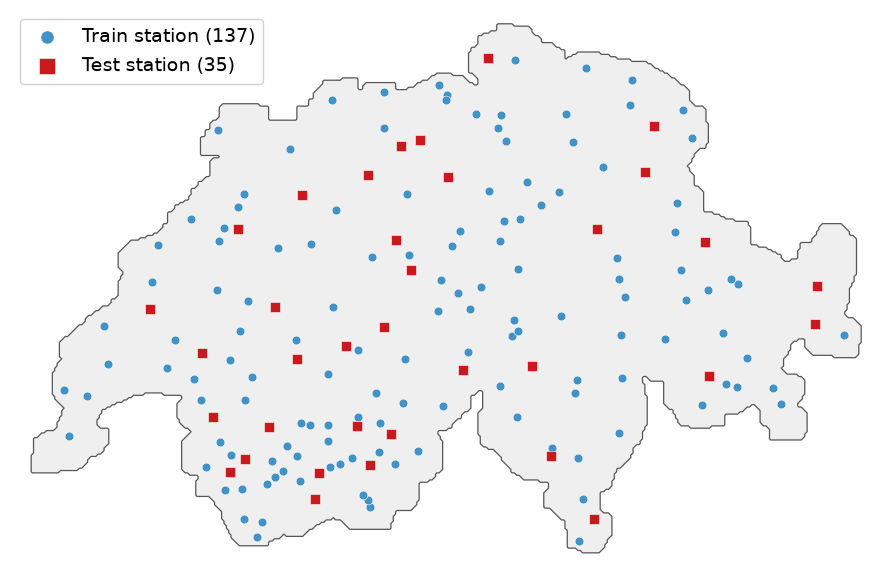

In [11]:
import geopandas as gpd
import xarray as xr
import glob

# --- Convert station lat/lon (WGS84) to Swiss LV95 (E, N) ---
train_meta = stations_meta.loc[train_stations]
test_meta  = stations_meta.loc[test_stations]

train_e, train_n = ds.wgs84_to_lv95(
    train_meta['longitude'].values, train_meta['latitude'].values
)
test_e, test_n = ds.wgs84_to_lv95(
    test_meta['longitude'].values, test_meta['latitude'].values
)

# --- Switzerland border from MeteoSwiss land mask ---
_ms_glob = params.METEO_SWISS_MEAN_TEMP_GLOB or './datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc'
_ms_file = sorted(glob.glob(_ms_glob))[0]
_ms_ds   = xr.open_dataset(_ms_file)
_var     = 'TabsD' if 'TabsD' in _ms_ds else list(_ms_ds.data_vars)[0]
_ms_slice = _ms_ds[_var].isel(time=0).values

_ms_E = _ms_ds['E'].values if 'E' in _ms_ds.coords else _ms_ds['x'].values
_ms_N = _ms_ds['N'].values if 'N' in _ms_ds.coords else _ms_ds['y'].values
_ms_ds.close()

_valid = (~np.isnan(_ms_slice)).astype(float)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.pcolormesh(_ms_E, _ms_N, _valid, cmap='Greys', vmin=0, vmax=2,
              shading='auto', alpha=0.15, zorder=1)
ax.contour(_ms_E, _ms_N, _valid, levels=[0.5],
           colors='#555555', linewidths=0.9, zorder=2)

ax.scatter(train_e, train_n, c='#4292c6', marker='o', s=40, zorder=3,
           label=f'Train station ({len(train_stations)})',
           edgecolors='white', linewidths=0.4)
ax.scatter(test_e, test_n, c='#cb181d', marker='s', s=60, zorder=4,
           label=f'Test station ({len(test_stations)})',
           edgecolors='white', linewidths=0.4)

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
#ax.set_title('PeakWeather station split — train / test')
ax.legend(loc='upper left', framealpha=0.9)
ax.set_aspect('equal')
ax.grid(True, linewidth=0.3, alpha=0.4)
ax.axis('off')
ax.legend(loc='upper left', framealpha=0.9, fontsize=14, markerscale=1.5)

plt.tight_layout()
plt.savefig(plot_path('station_split_map'), dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Convert MeteoSwiss land-mask grid from LV95 → WGS84 for lon/lat plots
_E_2d, _N_2d = np.meshgrid(_ms_E, _ms_N)
border_lons_2d, border_lats_2d = ds.lv95_to_wgs84(_E_2d, _N_2d)
border_valid_2d = _valid

In [13]:
# Build context from PW train stations
x_context, y_context = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean,
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    tpi_abs_max=tpi_abs_max,
    metadata=metadata,
    seasonal_features=seasonal_features,
    dates_pd=pw_dates_pd,
    device=device,
)
y_context = y_context.unsqueeze(-1)
y_context = torch.nan_to_num(y_context, nan=0.0)
print(f"x_context: {x_context.shape}  # (T, N_train, 6)")


x_context: torch.Size([2921, 137, 6])  # (T, N_train, 6)


In [14]:
x_target_static = ds.prepare_peakweather_targets(
    stations_meta=stations_meta.loc[test_stations],
    hi_res_tpi=hi_res_tpi,
    tpi_abs_max=tpi_abs_max,
    metadata=metadata,
    device=device,
)
n_test = x_target_static.shape[0]

def make_x_target_day(day_idx: int) -> torch.Tensor:
    if seasonal_features is not None:
        seas = seasonal_features[day_idx].unsqueeze(0).expand(n_test, -1)
        return torch.cat([x_target_static, seas], dim=-1)
    return x_target_static

print(f"x_target_static: {x_target_static.shape}  # (n_test_stations, 4)")

x_target_static: torch.Size([35, 4])  # (n_test_stations, 4)


In [15]:
%pip install -q geodatasets



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
COMPUTE_KRIGING  = False   # set to False to skip (predictions still work, skill score N/A)
KRIGING_DEFAULT  = 1.0    # constant baseline value used when COMPUTE_KRIGING=False (°C)

if COMPUTE_KRIGING:
    print("Computing regression kriging baseline (this may take a few minutes)...")
    all_baselines = inf.compute_kriging_baseline(
        daily_tmax=daily_tmean,
        train_stations=train_stations,
        test_stations=test_stations,
        stations_meta=stations_meta,
        dates_pd=pw_dates_pd,
    )
    print(f"Baseline shape: {all_baselines.shape}  # (n_days_total, n_test_stations)")
else:
    all_baselines = np.full((len(pw_dates_pd), len(test_stations)), KRIGING_DEFAULT, dtype=np.float32)
    print(f"Kriging skipped — constant baseline {KRIGING_DEFAULT}°C used.")
    print("MAE / RMSE / CRPS are still valid. Skill score will not be meaningful.")

Kriging skipped — constant baseline 1.0°C used.
MAE / RMSE / CRPS are still valid. Skill score will not be meaningful.


## Generate Predictions for Each Fold

For each fold, we load the trained model, plot a single representative holdout day, and accumulate predictions over the full holdout period for combined analysis.

Fold 1/5
Built SMACNP with 3,177,923 trainable parameters


  Loaded epoch 28 | holdout 2017-01-01 00:00:00 → 2018-08-07 00:00:00


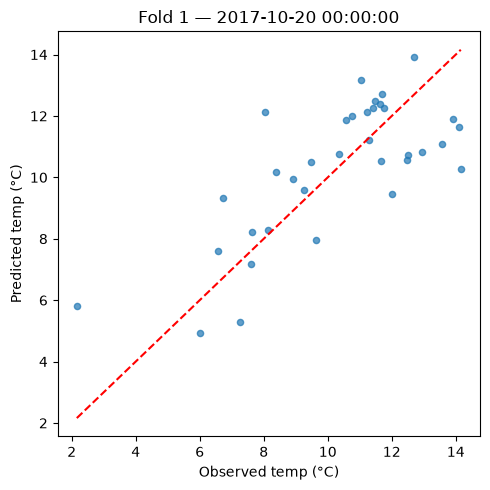

  Fold 1 done: 584 days
Fold 2/5
Built SMACNP with 3,177,923 trainable parameters
  Loaded epoch 29 | holdout 2018-08-08 00:00:00 → 2020-03-13 00:00:00


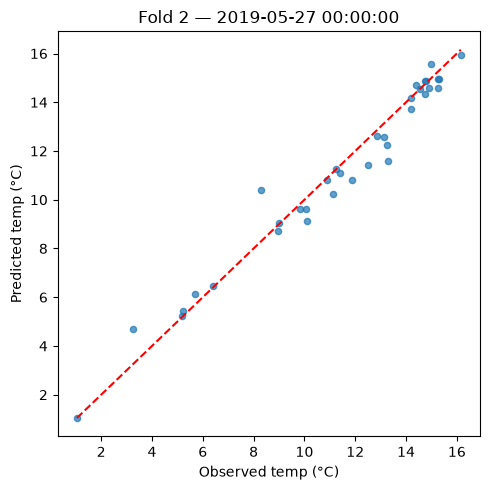

  Fold 2 done: 584 days
Fold 3/5
Built SMACNP with 3,177,923 trainable parameters
  Loaded epoch 27 | holdout 2020-03-14 00:00:00 → 2021-10-18 00:00:00


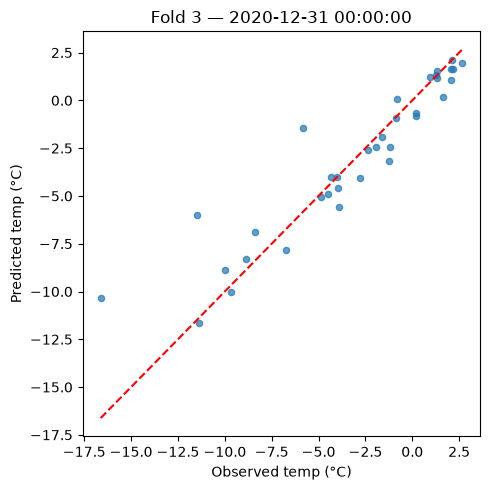

  Fold 3 done: 584 days
Fold 4/5
Built SMACNP with 3,177,923 trainable parameters
  Loaded epoch 26 | holdout 2021-10-19 00:00:00 → 2023-05-25 00:00:00


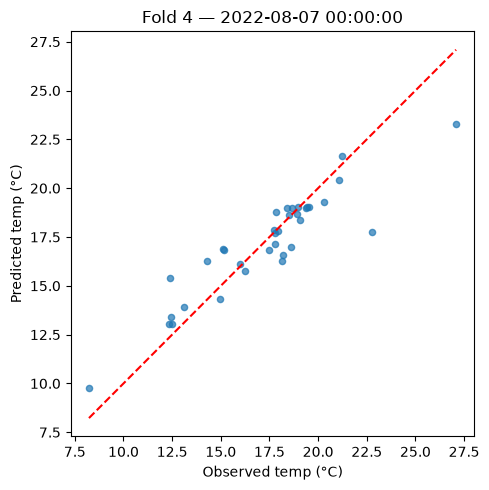

  Fold 4 done: 584 days
Fold 5/5
Built SMACNP with 3,177,923 trainable parameters
  Loaded epoch 27 | holdout 2023-05-26 00:00:00 → 2024-12-30 00:00:00


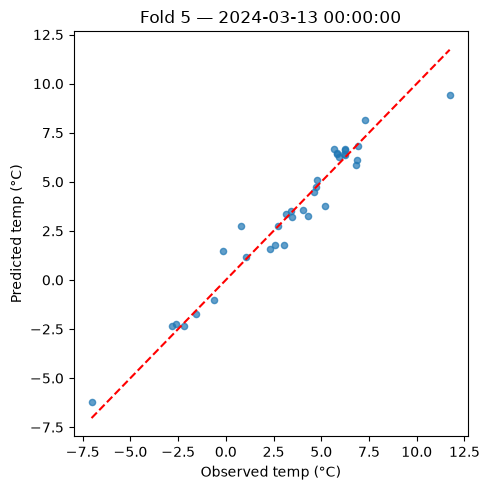

  Fold 5 done: 585 days

Combined: 2921 days x 35 test stations


In [17]:
n_samples = x_context.shape[0]
combined_preds, combined_sigmas, combined_truths, combined_dates = [], [], [], []
combined_baselines = []

for fold in range(params.N_FOLDS):
    print(f"{'='*60}\nFold {fold+1}/{params.N_FOLDS}\n{'='*60}")

    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue

    model, epoch = model_factory.load_model_checkpoint(
        checkpoint_path, params, device, input_dim=x_context.shape[-1]
    )
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    print(f"  Loaded epoch {epoch} | holdout {pw_dates_pd[holdout_start]} → {pw_dates_pd[holdout_end-1]}")

    fold_preds, fold_sigmas, fold_truths, fold_dates = [], [], [], []
    fold_baselines = []

    with torch.no_grad():
        for day_idx in range(holdout_start, holdout_end):
            date = pw_dates_pd[day_idx]
            true_vals = daily_tmean.loc[date, test_stations].values.astype(np.float32)
            if np.all(np.isnan(true_vals)):
                continue


            xc = x_context[day_idx:day_idx+1].to(device)
            yc = y_context[day_idx:day_idx+1].to(device)
            xt = make_x_target_day(day_idx).unsqueeze(0)


            out = model(xc, yc, xt)                        
            mu_norm    = out[0, :, 0].cpu().numpy()
            sigma_norm = out[0, :, 1].cpu().numpy()

            preds_degC = metadata.denormalize(
                torch.tensor(mu_norm)
            ).numpy() - ds.KELVIN_OFFSET

            fold_preds.append(preds_degC)
            fold_sigmas.append(sigma_norm)
            fold_truths.append(true_vals)
            fold_dates.append(date)
            fold_baselines.append(all_baselines[day_idx])

    if not fold_preds:
        print(f"  No data — skipping")
        continue

    # Single-day scatter plot
    mid = len(fold_preds) // 2
    valid = ~np.isnan(fold_truths[mid])
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(fold_truths[mid][valid], fold_preds[mid][valid], alpha=0.7, s=20)
    lims = [min(fold_truths[mid][valid].min(), fold_preds[mid][valid].min()),
            max(fold_truths[mid][valid].max(), fold_preds[mid][valid].max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('Observed temp (°C)'); ax.set_ylabel('Predicted temp (°C)')
    ax.set_title(f'Fold {fold+1} — {fold_dates[mid]}')
    plt.tight_layout(); plt.savefig(plot_path(f'fold{fold}_scatter')); plt.show()

    combined_preds.append(np.stack(fold_preds))
    combined_sigmas.append(np.stack(fold_sigmas))
    combined_truths.append(np.stack(fold_truths))
    combined_dates.extend(fold_dates)
    combined_baselines.append(np.stack(fold_baselines))
    print(f"  Fold {fold+1} done: {len(fold_preds)} days")

all_preds   = np.concatenate(combined_preds,  axis=0)
all_sigmas  = np.concatenate(combined_sigmas, axis=0)
all_truths  = np.concatenate(combined_truths, axis=0)
all_errors  = all_preds - all_truths
sigma_degC  = all_sigmas * metadata.data_std
all_baselines_holdout = np.concatenate(combined_baselines, axis=0)
total_days  = all_preds.shape[0]
print(f"\nCombined: {total_days} days x {all_preds.shape[1]} test stations")


## Combined Holdout Analysis (All Folds)

The following plots use the concatenated holdout predictions from all folds, covering the entire year.

Overall MAE:          1.024 °C
Overall RMSE:         1.350 °C
Overall Bias:         0.001 °C
Overall CRPS:         0.750 °C
Global skill score:   0.914


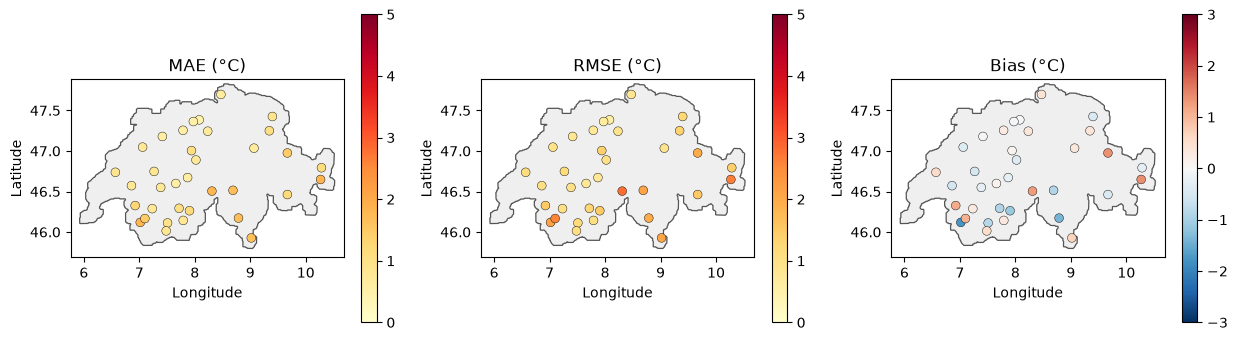

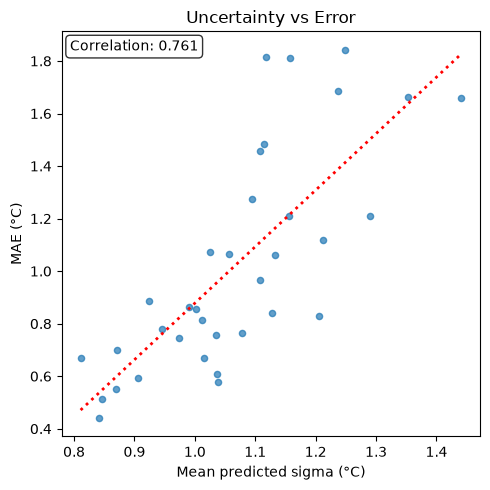

Per-station uncertainty-error correlation: 0.761


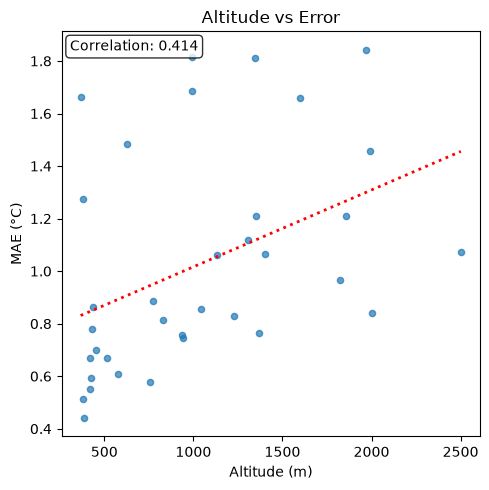

Altitude-error correlation: 0.414


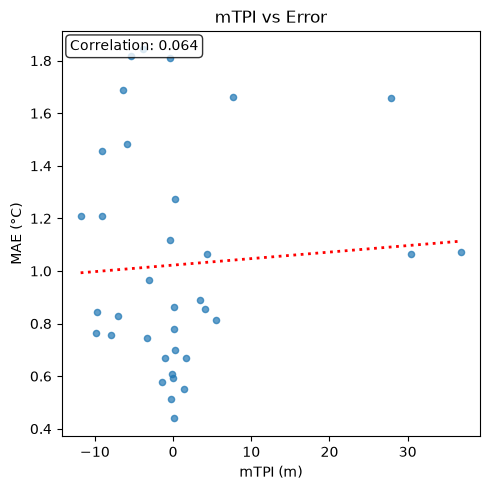

mTPI-error correlation: 0.064
  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v26/plots/doy_vs_error.png


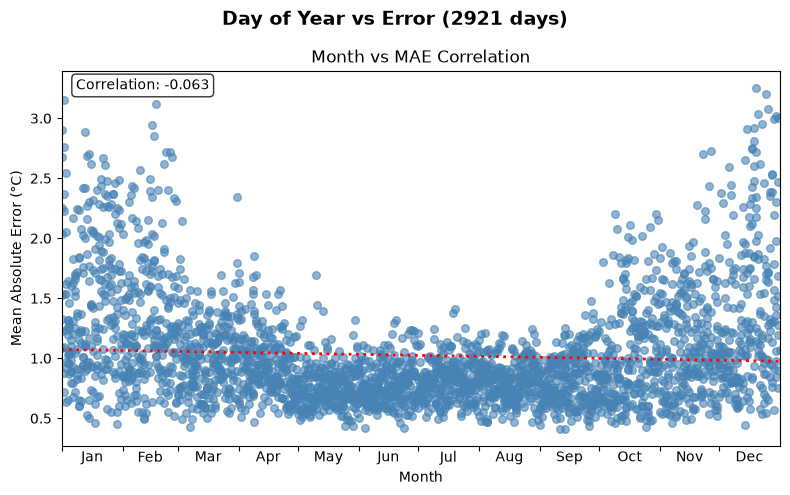

Day of year-error correlation: -0.063


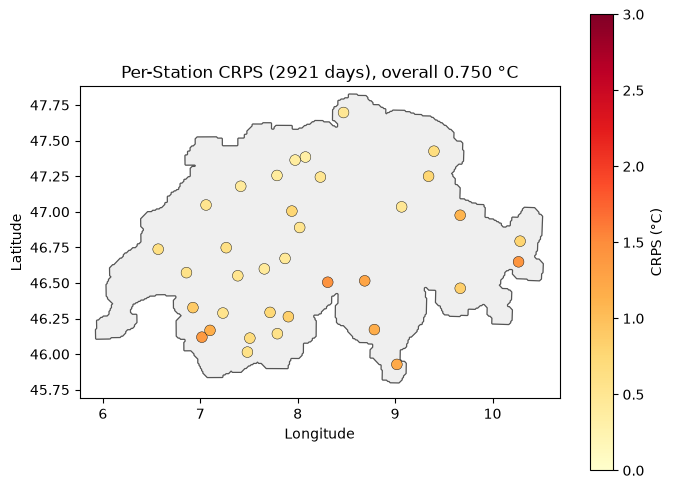

  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v26/plots/skill_map.png


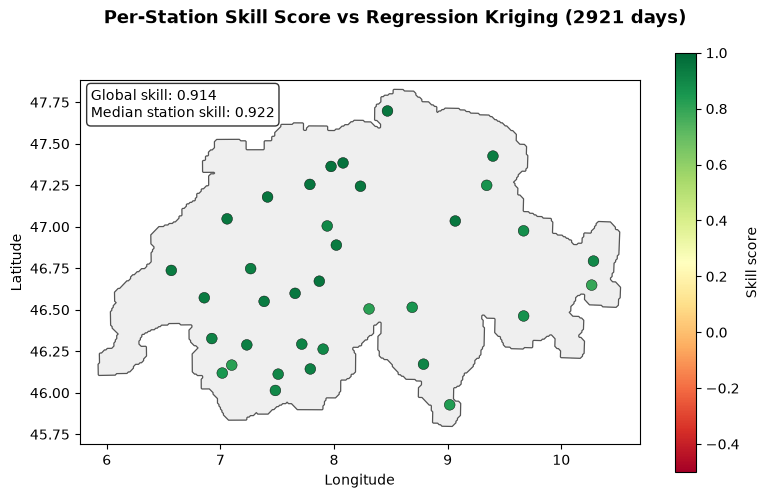

Saved station metrics to trained_models/test-2017-50e-5f-smacnp-pw-mean-v26/station_metrics.npz


In [18]:
station_lats = stations_meta.loc[test_stations, 'latitude'].values
station_lons = stations_meta.loc[test_stations, 'longitude'].values
station_alts = stations_meta.loc[test_stations, 'station_height'].values
station_tpi  = (x_target_static[:, 3].cpu().numpy() * 400.0) - 200.0  # denorm mTPI

m = metrics.compute_station_metrics(
    all_errors=all_errors,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    all_truths=all_truths,
    all_ref_preds=all_baselines_holdout,
)

mae_per_station   = m.mae
rmse_per_station  = m.rmse
bias_per_station  = m.bias
crps_per_station  = m.crps
sigma_per_station = m.mean_sigma

kriging_errors = all_baselines_holdout - all_truths   # already in °C
kriging_mae    = np.nanmean(np.abs(kriging_errors))
kriging_rmse   = np.sqrt(np.nanmean(kriging_errors**2))
kriging_bias   = np.nanmean(kriging_errors)

print(f"Overall MAE:          {np.nanmean(mae_per_station):.3f} °C")
print(f"Overall RMSE:         {np.nanmean(rmse_per_station):.3f} °C")
print(f"Overall Bias:         {np.nanmean(bias_per_station):.3f} °C")
print(f"Overall CRPS:         {m.overall_crps:.3f} °C")
print(f"Global skill score:   {m.global_skill:.3f}")
#print()
#print(f"--- Kriging ---")
#print(f"Kriging MAE:          {kriging_mae:.3f} °C")
#print(f"Kriging RMSE:         {kriging_rmse:.3f} °C")
#print(f"Kriging Bias:         {kriging_bias:.3f} °C")


# 1. Station error map
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
center_lat = (station_lats.min() + station_lats.max()) / 2
geo_aspect = 1.0 / np.cos(np.radians(center_lat))
for ax, vals, title, cmap, vmin, vmax in zip(
    axes,
    [mae_per_station, rmse_per_station, bias_per_station],
    ['MAE (°C)', 'RMSE (°C)', 'Bias (°C)'],
    ['YlOrRd', 'YlOrRd', 'RdBu_r'],
    [0, 0, -3], [5, 5, 3],
):
    ax.contourf(border_lons_2d, border_lats_2d, border_valid_2d,
                levels=[0.5, 1.5], colors=['#cccccc'], alpha=0.3, zorder=1)
    ax.contour(border_lons_2d, border_lats_2d, border_valid_2d,
            levels=[0.5], colors='#555555', linewidths=0.9, zorder=2)
    sc = ax.scatter(station_lons, station_lats, c=vals, cmap=cmap,
                    vmin=vmin, vmax=vmax, s=40, edgecolors='k', linewidths=0.3, zorder=3)
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect(geo_aspect)
    ax.set_facecolor('white')

# 2. Uncertainty vs error (per station)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(sigma_per_station, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('Mean predicted sigma (°C)')
ax.set_ylabel('MAE (°C)')
corr = np.corrcoef(sigma_per_station, mae_per_station)[0, 1]
slope, intercept = np.polyfit(sigma_per_station, mae_per_station, 1)
x_line = np.linspace(sigma_per_station.min(), sigma_per_station.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r:', linewidth=2)
ax.set_title('Uncertainty vs Error')
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(plot_path('uncertainty_vs_error'))
plt.show()
print(f"Per-station uncertainty-error correlation: {corr:.3f}")

# 3. Altitude vs error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(station_alts, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('Altitude (m)')
ax.set_ylabel('MAE (°C)')
corr_alt = np.corrcoef(station_alts, mae_per_station)[0, 1]
slope, intercept = np.polyfit(station_alts, mae_per_station, 1)
x_line = np.linspace(station_alts.min(), station_alts.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r:', linewidth=2)
ax.set_title('Altitude vs Error')
ax.text(0.02, 0.98, f'Correlation: {corr_alt:.3f}', transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(plot_path('altitude_vs_error'))
plt.show()
print(f"Altitude-error correlation: {corr_alt:.3f}")

# 4. mTPI vs error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(station_tpi, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('mTPI (m)')
ax.set_ylabel('MAE (°C)')
corr_tpi = np.corrcoef(station_tpi, mae_per_station)[0, 1]
slope, intercept = np.polyfit(station_tpi, mae_per_station, 1)
x_line = np.linspace(station_tpi.min(), station_tpi.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r:', linewidth=2)
ax.set_title('mTPI vs Error')
ax.text(0.02, 0.98, f'Correlation: {corr_tpi:.3f}', transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(plot_path('mtpi_vs_error'))
plt.show()
print(f"mTPI-error correlation: {corr_tpi:.3f}")

# 5. Day of year vs error (reuses existing visualization function)
all_holdout_dates = np.array(combined_dates, dtype='datetime64')
fig_doy, doy_corr = vis.plot_temporal_error_analysis(
    all_errors=all_errors,
    holdout_dates=all_holdout_dates,
    title=f'Day of Year vs Error ({total_days} days)',
    save_path=plot_path('doy_vs_error'),
)
plt.show()
print(f"Day of year-error correlation: {doy_corr:.3f}")

# 6. CRPS station map
fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(border_lons_2d, border_lats_2d, border_valid_2d,
            levels=[0.5, 1.5], colors=['#cccccc'], alpha=0.3, zorder=1)
ax.contour(border_lons_2d, border_lats_2d, border_valid_2d,
           levels=[0.5], colors='#555555', linewidths=0.9, zorder=2)
sc = ax.scatter(station_lons, station_lats, c=crps_per_station,
                cmap='YlOrRd', vmin=0, vmax=3, s=60,
                edgecolors='k', linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label='CRPS (°C)')
ax.set_title(f'Per-Station CRPS ({total_days} days), '
             f'overall {np.nanmean(crps_per_station):.3f} °C')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect(geo_aspect)
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig(plot_path('crps_map'))
plt.show()


# 7. Skill score map
fig_skill = vis.plot_station_skill_map(
    skill_per_station=m.skill,
    station_lats=station_lats,
    station_lons=station_lons,
    global_skill=m.global_skill,
    title=f'Per-Station Skill Score vs Regression Kriging ({total_days} days)',
    swiss_border_lons_2d=border_lons_2d,
    swiss_border_lats_2d=border_lats_2d,
    swiss_border_valid=border_valid_2d,
    save_path=plot_path('skill_map'),
)
plt.show()

# Save per-station metrics for cross-model comparison
import numpy as np
station_metrics_path = MODEL_DIR / 'station_metrics.npz'
np.savez(
    station_metrics_path,
    mae=mae_per_station,
    rmse=rmse_per_station,
    crps=crps_per_station,
    lats=station_lats,
    lons=station_lons,
)
print(f"Saved station metrics to {station_metrics_path}")


  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v26/plots/qq_calibration.png


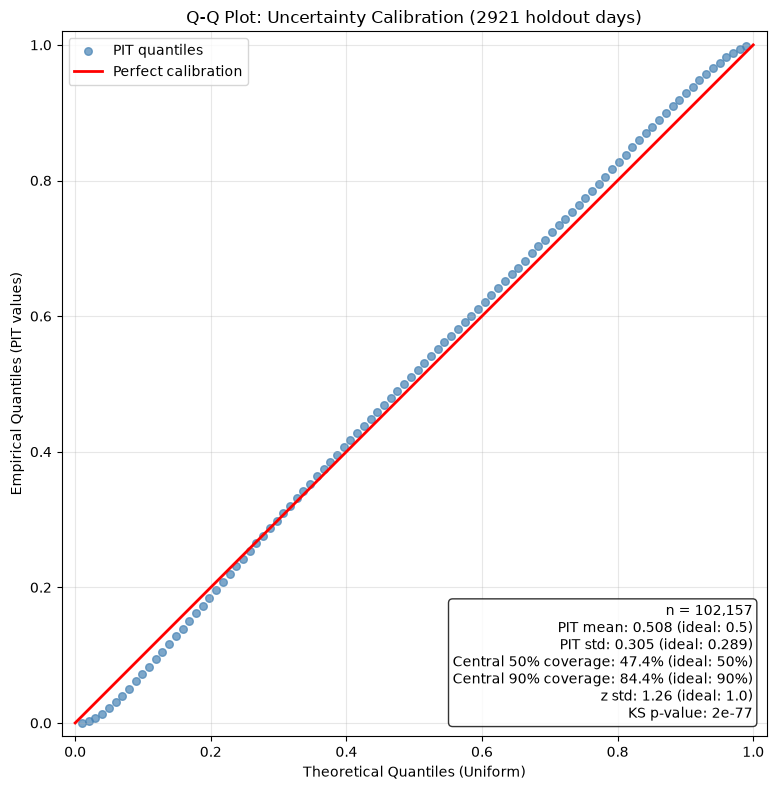


Calibration statistics:
  PIT mean: 0.508 (ideal: 0.5)
  PIT std:  0.305 (ideal: 0.289)
  z std:    1.26 (ideal: 1.0)
  50% coverage: 47.4% (ideal: 50%)
  90% coverage: 84.4% (ideal: 90%)
  KS test p-value: 2e-77


In [19]:
from importlib import reload
vis = reload(vis)
# 8. Q-Q plot for uncertainty calibration
# Assesses whether the model's predicted uncertainty (sigma) is correctly calibrated.
# For a well-calibrated Gaussian model, PIT values (CDF of truth under predicted distribution)
# should follow Uniform(0, 1).
fig_qq, calibration_stats = vis.plot_qq_calibration(
    all_truths=all_truths,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    title=f"Q-Q Plot: Uncertainty Calibration ({total_days} holdout days)",
    save_path=plot_path("qq_calibration"),
)
plt.show()

print("\nCalibration statistics:")
print(f"  PIT mean: {calibration_stats['pit_mean']:.3f} (ideal: 0.5)")
print(f"  PIT std:  {calibration_stats['pit_std']:.3f} (ideal: 0.289)")
print(f"  z std:    {calibration_stats['z_std']:.2f} (ideal: 1.0)")
print(f"  50% coverage: {calibration_stats['coverage_50']:.1%} (ideal: 50%)")
print(f"  90% coverage: {calibration_stats['coverage_90']:.1%} (ideal: 90%)")
print(f"  KS test p-value: {calibration_stats['ks_p']:.3g}")

  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v26/plots/reliability_diagram.png


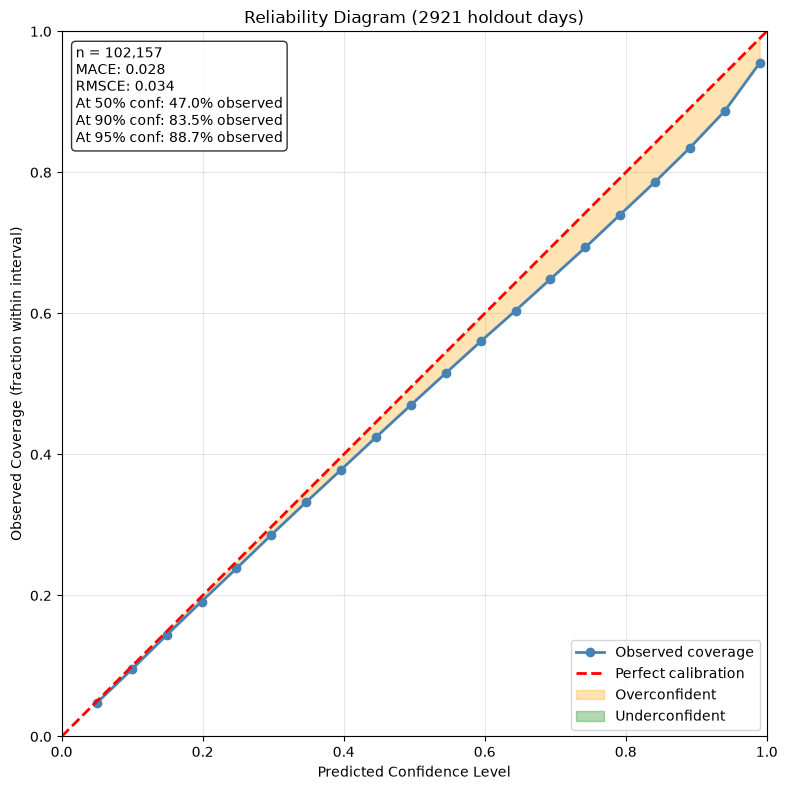


Reliability statistics:
  Mean Absolute Calibration Error (MACE): 0.028
  At 50% confidence: 47.0% observed (ideal: 50%)
  At 90% confidence: 83.5% observed (ideal: 90%)
  At 95% confidence: 88.7% observed (ideal: 95%)


In [20]:
# 9. Reliability diagram for uncertainty calibration
# Shows predicted confidence level vs observed coverage.
# If well-calibrated, the curve should follow the diagonal.
fig_reliability, reliability_stats = vis.plot_reliability_diagram(
    all_truths=all_truths,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    title=f"Reliability Diagram ({total_days} holdout days)",
    save_path=plot_path("reliability_diagram"),
)
plt.show()

print("\nReliability statistics:")
print(f"  Mean Absolute Calibration Error (MACE): {reliability_stats['mace']:.3f}")
print(f"  At 50% confidence: {reliability_stats['coverage_at_50']:.1%} observed (ideal: 50%)")
print(f"  At 90% confidence: {reliability_stats['coverage_at_90']:.1%} observed (ideal: 90%)")
print(f"  At 95% confidence: {reliability_stats['coverage_at_95']:.1%} observed (ideal: 95%)")

  Saved plot: trained_models/test-2017-50e-5f-smacnp-pw-mean-v26/plots/predicted_vs_observed.png


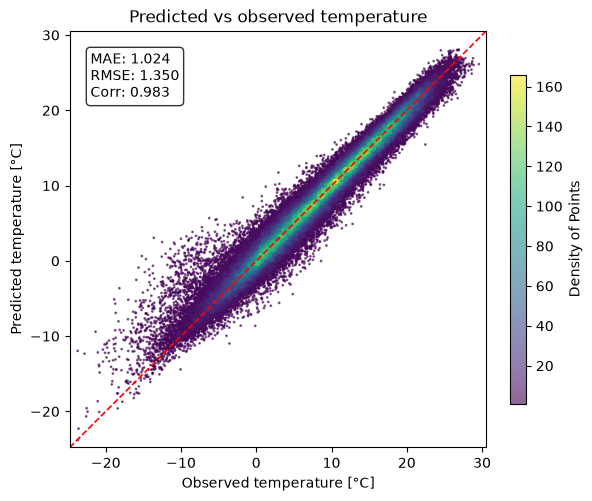

In [21]:
fig = vis.plot_predicted_vs_observed(
    all_preds=all_preds,
    all_truths=all_truths,
    title='Predicted vs observed temperature',
    save_path=plot_path('predicted_vs_observed'),
)


In [22]:
import json

metrics_path = MODEL_DIR / 'metrics.json'

metrics_dict = {
    "config": {
        "model_name": MODEL_NAME,
        "inference_dataset": "peakweather",
        "context": "peakweather_train_stations",
        "n_context_stations": len(train_stations),
        "n_test_stations": len(test_stations),
        "station_split_seed": STATION_SPLIT_SEED,
        "n_folds": params.N_FOLDS,
        "holdout_days": int(total_days),
        "pw_first_date": PW_FIRST_DATE,
        "pw_last_date": PW_LAST_DATE,
        "pw_validity_threshold": PW_VALIDITY_THRESHOLD,
    },
    "overall": {
        "mae":  float(np.nanmean(mae_per_station)),
        "rmse": float(np.nanmean(rmse_per_station)),
        "bias": float(np.nanmean(bias_per_station)),
        "crps": float(np.nanmean(crps_per_station)),
        "skill_score": float(m.global_skill),
    },
    "correlations": {
        "uncertainty_error": float(corr),
        "altitude_error":    float(corr_alt),
        "mtpi_error":        float(corr_tpi),
        "doy_error":         float(doy_corr),
    },
    "calibration": {
        "pit_mean":    float(calibration_stats["pit_mean"]),
        "pit_std":     float(calibration_stats["pit_std"]),
        "z_std":       float(calibration_stats["z_std"]),
        "coverage_50": float(calibration_stats["coverage_50"]),
        "coverage_90": float(calibration_stats["coverage_90"]),
        "ks_p_value":  float(calibration_stats["ks_p"]),
    },
    "reliability": {
        "mace":            float(reliability_stats["mace"]),
        "coverage_at_50":  float(reliability_stats["coverage_at_50"]),
        "coverage_at_90":  float(reliability_stats["coverage_at_90"]),
        "coverage_at_95":  float(reliability_stats["coverage_at_95"]),
    },
}
metrics_path.write_text(json.dumps(metrics_dict, indent=2))
print(f"Metrics saved to {metrics_path}")

Metrics saved to trained_models/test-2017-50e-5f-smacnp-pw-mean-v26/metrics.json


In [23]:
# Load one fold's model without running the full prediction loop
grid_shape = (240, 370)

fold = 4   # any fold works for attention visualization
checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
model, epoch = model_factory.load_model_checkpoint(
    checkpoint_path, params, device, input_dim=x_context.shape[-1]
)
print(f"Loaded model from fold {fold}, epoch {epoch}")

Built SMACNP with 3,177,923 trainable parameters
Loaded model from fold 4, epoch 27


In [24]:
from importlib import reload
import visualization as vis
reload(vis)
from visualization import load_attention_context

FOLD = 4

context = load_attention_context(model_name=MODEL_NAME, fold=FOLD)

# Build LOCATIONS — default first, then all 35 test stations
test_meta = context['stations_meta'].loc[
    context['test_stations'],
    ['station_name', 'latitude', 'longitude']
]
LOCATIONS = {'Zrh': (47.376, 8.541)}
for sid, row in test_meta.iterrows():
    LOCATIONS[sid] = (row['latitude'], row['longitude'])


print("\nAvailable test stations:")
for sid, row in test_meta.iterrows():
    print(f"  {sid:6s}  {row['station_name']:<35s}  ({row['latitude']:.3f}°N, {row['longitude']:.3f}°E)")


Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...
  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2921, 172)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Station split: 137 train / 0 val / 35 test
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32
Built SMACNP with 3,177,923 trainable parameters
Loaded test-2017-50e-5f-smacnp-pw-mean-v26 — fold 4, epoch 27

Available test stations:
  AIG     Aigle                                (46.327°N, 6.924°E)
  BIV     Bivio                                (46.462°N, 9.669°E)
  BUF     Buffalora                            (46.648°N, 10.267°E)
  BUS     Buchs / Aarau                        (47.384°N, 8.080°E)
  CRM     

(47.249°N, 9.343°E): idx=22, matched (47.2494°N, 9.3435°E), 0.00 km


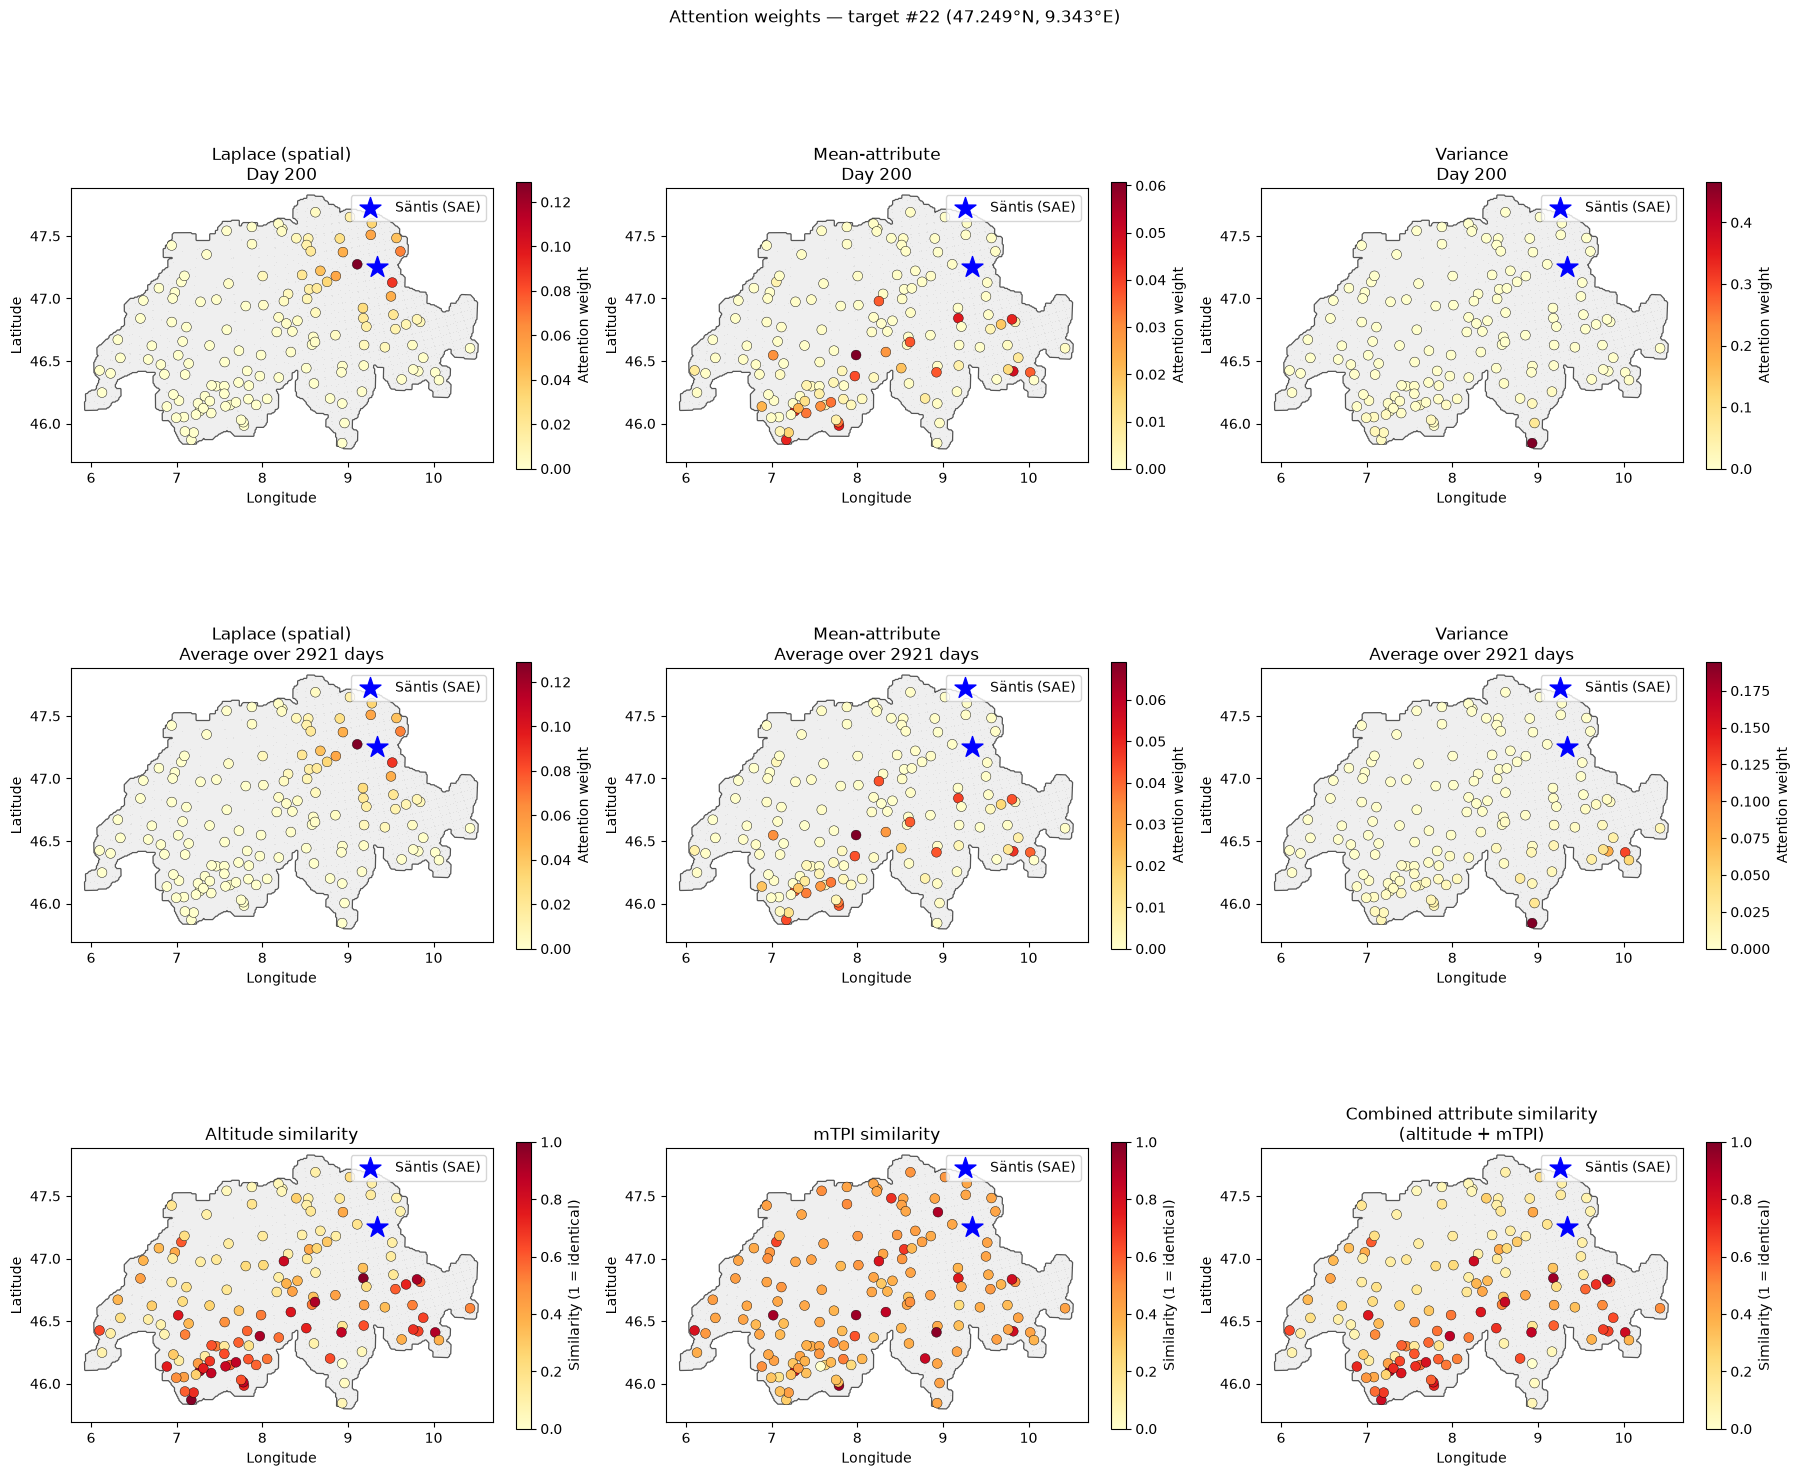

In [27]:
from visualization import plot_attention

LOCATION        = 'SAE'   # station code from the list printed above
DAY_IDX         = 200
SHOW_AVERAGE    = True
SHOW_SIMILARITY = True

fig = plot_attention(
    context,
    location=LOCATIONS[LOCATION],
    day_idx=DAY_IDX,
    show_average=SHOW_AVERAGE,
    show_similarity=SHOW_SIMILARITY,
)

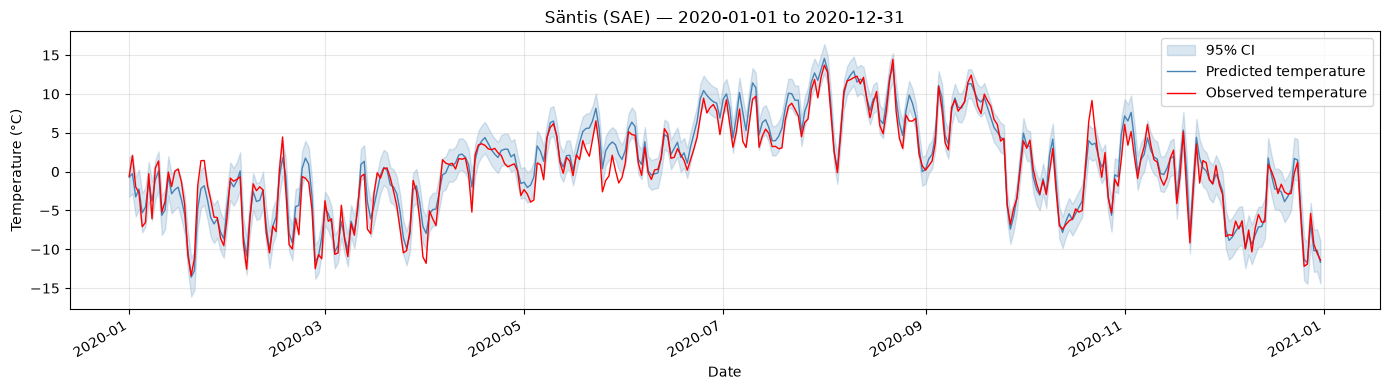

In [26]:
# ── Time-series plot: predicted vs observed for a single station ────────────
STATION_CODE  = 'SAE'
DATE_START    = '2020-01-01'
DATE_END      = '2020-12-31'

# Locate the station index among test stations
station_idx = list(test_stations).index(STATION_CODE)
station_name = stations_meta.loc[STATION_CODE, 'station_name']

# Filter to the requested date window (combined_dates may be non-contiguous across folds)
dates_arr = pd.DatetimeIndex(combined_dates)
mask = (dates_arr >= DATE_START) & (dates_arr <= DATE_END)
dates_plot  = dates_arr[mask]
preds_plot  = all_preds[mask, station_idx]
sigma_plot  = sigma_degC[mask, station_idx]
truths_plot = all_truths[mask, station_idx]

fig, ax = plt.subplots(figsize=(14, 4))

# Uncertainty band: mean ± 2σ
ax.fill_between(
    dates_plot,
    preds_plot - 2 * sigma_plot,
    preds_plot + 2 * sigma_plot,
    alpha=0.2, color='steelblue', label='95% CI',
)

# Predicted mean and observations
ax.plot(dates_plot, preds_plot, color='steelblue', linewidth=1, label='Predicted temperature')
ax.plot(dates_plot, truths_plot, color='red', linewidth=1, label='Observed temperature')


ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'{station_name} ({STATION_CODE}) — {DATE_START} to {DATE_END}')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Summary

This notebook demonstrates how to:
1. Load trained SMACNP models using saved configuration (one per fold)
2. Reconstruct the holdout time periods used during cross-validation
3. Build PeakWeather train-station context for each holdout day
4. **Per-fold:** Generate predictions at the 35 held-out PeakWeather test stations
   and plot a scatter of observed vs predicted temperatures for a representative day
5. **Combined across all folds:** Since holdout periods are non-overlapping,
   predictions from all folds are concatenated to produce a unified evaluation:
   - Per-station error maps (MAE, RMSE, Bias)
   - Uncertainty calibration (predicted σ vs actual MAE per station)
   - Error correlations with altitude and mTPI
   - Temporal error patterns (day-of-year analysis)
   - CRPS (Continuous Ranked Probability Score) for probabilistic calibration
   - Skill score relative to regression kriging baseline
   - Q-Q plot using Probability Integral Transform (PIT)
   - Reliability diagram for confidence calibration

### Interpretation of correlation plots:
- **Uncertainty vs Error:** High correlation indicates good calibration — the model "knows where it doesn't know"
- **Altitude vs Error:** Positive correlation suggests the model struggles more at high elevations
- **mTPI vs Error:** Positive values = ridges, negative = valleys. Correlation reveals terrain-dependent biases
- **Day of Year vs Error:** Reveals seasonal performance variations across the holdout period

### Interpretation of calibration plots:

**Q-Q Plot (PIT-based):**
- Computes PIT = CDF(truth | μ, σ) for each prediction
- If well-calibrated, PIT values should be Uniform(0,1)
- Points on diagonal = well-calibrated
- S-curve below diagonal = overconfident (intervals too narrow)
- S-curve above diagonal = underconfident (intervals too wide)

**Reliability Diagram:**
- X-axis: Predicted confidence level (e.g., 50%, 90%, 95%)
- Y-axis: Observed frequency (fraction of truths actually in that interval)
- Diagonal = perfect calibration
- Curve below diagonal (orange region) = overconfident
- Curve above diagonal (green region) = underconfident
- MACE (Mean Absolute Calibration Error) summarises miscalibration
